In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from market_data import *
from pricer import *
MarketData.initialize()

In [3]:
und = Stock.BLUECHIP_BANK
ls = LongShort.LONG
spot = MarketData.get_spot()[und]
model = FlatVolModel(und)
params = Params()

strikes = [0.9 * spot, spot, 1.1 * spot]
expiries = [0.5, 1.0]
put_calls = [PutCallFwd.CALL, PutCallFwd.PUT]

options = []
for pc in put_calls:
    for exp in expiries:
        for strk in strikes:
            options.append(EuropeanContract(und, pc, ls, strk, exp))
print(options)

[<contract.EuropeanContract object at 0x000001EADAD01580>, <contract.EuropeanContract object at 0x000001EADAD01100>, <contract.EuropeanContract object at 0x000001EADAD01610>, <contract.EuropeanContract object at 0x000001EADAD01640>, <contract.EuropeanContract object at 0x000001EADAD015E0>, <contract.EuropeanContract object at 0x000001EADACD2AF0>, <contract.EuropeanContract object at 0x000001EADACD2C40>, <contract.EuropeanContract object at 0x000001EADACD2340>, <contract.EuropeanContract object at 0x000001EADACD2E50>, <contract.EuropeanContract object at 0x000001EADACD29D0>, <contract.EuropeanContract object at 0x000001EADACD2CA0>, <contract.EuropeanContract object at 0x000001EADACD2C70>]


working out the code for a single option

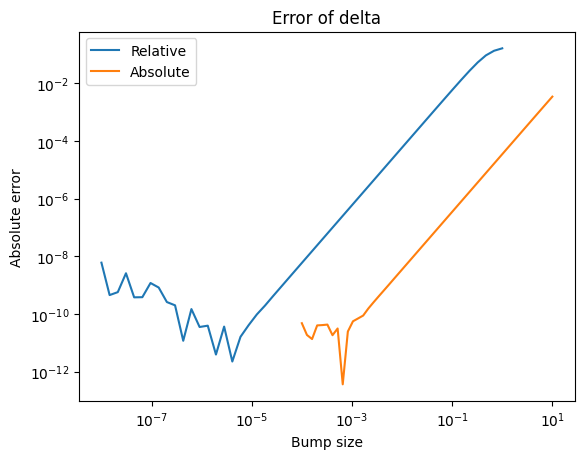

In [17]:
pricer = EuropeanAnalyticPricer(options[0],model, params)
errors_delta_relative = []
pricer.bumpsizemethod = BumpSizeMethod.RELATIVE
delta_analytic = pricer.calc_delta(GreekMethod.ANALYTIC)

for bump in np.logspace(-8, 0, 50):
    pricer.relative_bump_size = bump
    delta_bump = pricer.calc_delta(GreekMethod.BUMP)
    errors_delta_relative.append(abs(delta_analytic - delta_bump))

pricer.bumpsizemethod = BumpSizeMethod.ABSOLUTE
errors_delta_absolute = []
for bump in np.logspace(-4, 1, 50):
    pricer.relative_bump_size = bump
    delta_bump = pricer.calc_delta(GreekMethod.BUMP)
    errors_delta_absolute.append(abs(delta_analytic - delta_bump))

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Bump size')
plt.ylabel('Absolute error')
plt.title('Error of delta')
plt.plot(np.logspace(-8, 0, 50), errors_delta_relative, label='Relative')
plt.plot(np.logspace(-4, 1, 50), errors_delta_absolute, label='Absolute')
plt.legend()
plt.show()

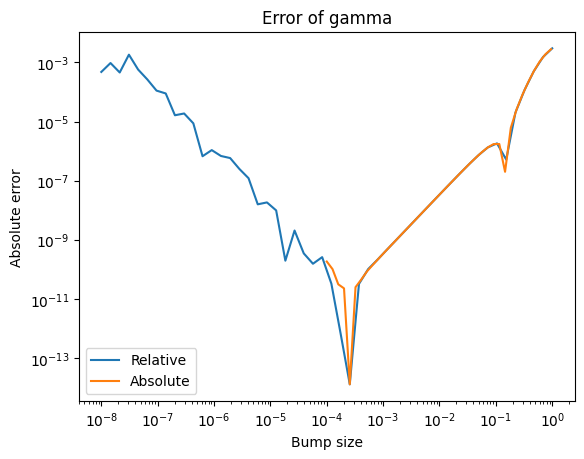

In [18]:
pricer = EuropeanAnalyticPricer(options[0],model, params)
errors_gamma_relative = []
pricer.bumpsizemethod = BumpSizeMethod.RELATIVE
gamma_analytic = pricer.calc_gamma(GreekMethod.ANALYTIC)

for bump in np.logspace(-8, 0, 50):
    pricer.relative_bump_size = bump
    gamma_bump = pricer.calc_gamma(GreekMethod.BUMP)
    errors_gamma_relative.append(abs(gamma_analytic - gamma_bump))

pricer.bumpsizemethod = BumpSizeMethod.ABSOLUTE
errors_gamma_absolute = []
for bump in np.logspace(-4, 1, 50):
    pricer.relative_bump_size = bump
    gamma_bump = pricer.calc_gamma(GreekMethod.BUMP)
    errors_gamma_absolute.append(abs(gamma_analytic - gamma_bump))

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Bump size')
plt.ylabel('Absolute error')
plt.title('Error of gamma')
plt.plot(np.logspace(-8, 0, 50), errors_gamma_relative, label='Relative')
plt.plot(np.logspace(-4, 1, 50), errors_gamma_absolute, label='Absolute')
plt.legend()
plt.show()

Running it for multiple options in bulk

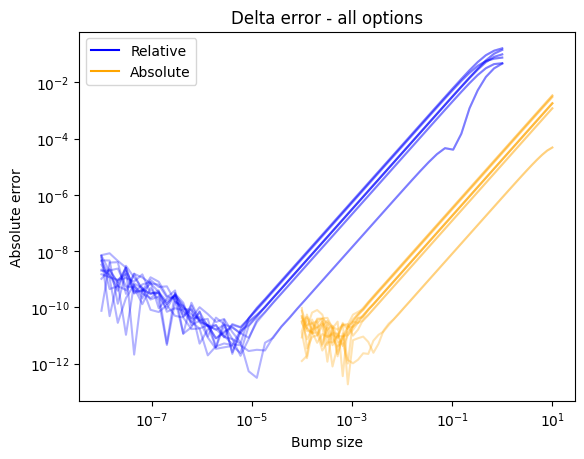

In [16]:
plt.figure()
for option in options:
    pricer = EuropeanAnalyticPricer(option, model, params)
    delta_analytic = pricer.calc_delta(GreekMethod.ANALYTIC)
    errors_relative = []
    errors_absolute = []
    
    pricer.bumpsizemethod = BumpSizeMethod.RELATIVE
    for bump in np.logspace(-8, 0, 50):
        pricer.relative_bump_size = bump
        delta_bump = pricer.calc_delta(GreekMethod.BUMP)
        errors_relative.append(abs(delta_analytic - delta_bump))
    
    pricer.bumpsizemethod = BumpSizeMethod.ABSOLUTE
    for bump in np.logspace(-4, 1, 50):
        pricer.relative_bump_size = bump
        delta_bump = pricer.calc_delta(GreekMethod.BUMP)
        errors_absolute.append(abs(delta_analytic - delta_bump))
    
    plt.plot(np.logspace(-8, 0, 50), errors_relative, color='blue', alpha=0.3)
    plt.plot(np.logspace(-4, 1, 50), errors_absolute, color='orange', alpha=0.3)

plt.plot([], [], color='blue', label='Relative')
plt.plot([], [], color='orange', label='Absolute')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Bump size')
plt.ylabel('Absolute error')
plt.title('Delta error - all options')
plt.legend()
plt.show()

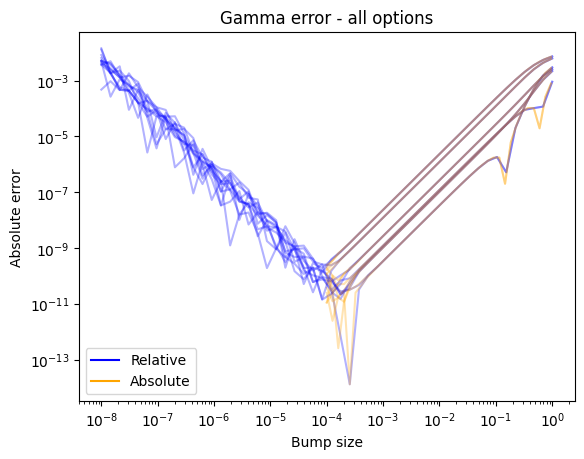

In [15]:
plt.figure()
for option in options:
    pricer = EuropeanAnalyticPricer(option, model, params)
    gamma_analytic = pricer.calc_gamma(GreekMethod.ANALYTIC)
    errors_relative = []
    errors_absolute = []
    
    pricer.bumpsizemethod = BumpSizeMethod.RELATIVE
    for bump in np.logspace(-8, 0, 50):
        pricer.relative_bump_size = bump
        gamma_bump = pricer.calc_gamma(GreekMethod.BUMP)
        errors_relative.append(abs(gamma_analytic - gamma_bump))
    
    pricer.bumpsizemethod = BumpSizeMethod.ABSOLUTE
    for bump in np.logspace(-4, 1, 50):
        pricer.relative_bump_size = bump
        gamma_bump = pricer.calc_gamma(GreekMethod.BUMP)
        errors_absolute.append(abs(gamma_analytic - gamma_bump))
    
    plt.plot(np.logspace(-8, 0, 50), errors_relative, color='blue', alpha=0.3)
    plt.plot(np.logspace(-4, 1, 50), errors_absolute, color='orange', alpha=0.3)

plt.plot([], [], color='blue', label='Relative')
plt.plot([], [], color='orange', label='Absolute')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Bump size')
plt.ylabel('Absolute error')
plt.title('Gamma error - all options')
plt.legend()
plt.show()

Delta: 
- optimal relative bump size: around 10^-5
- optimal absolute bump size: around 10^-3

Gamma 
- optimal relative bump size: around 10^-4

Relative bumping is better than absolute because it scales better with spot price change